In [1]:

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("job_salary_prediction_dataset1.csv")

df

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10.0,Bachelor,2.0,Healthcare,Medium,India,Hybrid,2.0,85270
1,Data Analyst,5.0,Bachelor,17.0,Telecom,Small,Australia,No,0.0,103860
2,Frontend Developer,18.0,PhD,4.0,Media,NaN,Australia,No,1.0,126390
3,Business Analyst,19.0,PhD,13.0,Retail,Medium,Canada,Yes,0.0,162191
4,Product Manager,15.0,Bachelor,7.0,Manufacturing,Large,Sweden,Yes,0.0,118734
...,...,...,...,...,...,...,...,...,...,...
249995,Software Engineer,17.0,PhD,2.0,Telecom,Enterprise,India,No,1.0,115590
249996,Frontend Developer,20.0,PhD,7.0,Telecom,Startup,Remote,No,2.0,152738
249997,Business Analyst,1.0,Bachelor,12.0,Retail,Enterprise,India,Yes,0.0,69923
249998,Data Scientist,0.0,High School,2.0,Consulting,Small,Sweden,Hybrid,5.0,46351


In [3]:
df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10.0,Bachelor,2.0,Healthcare,Medium,India,Hybrid,2.0,85270
1,Data Analyst,5.0,Bachelor,17.0,Telecom,Small,Australia,No,0.0,103860
2,Frontend Developer,18.0,PhD,4.0,Media,NaN,Australia,No,1.0,126390
3,Business Analyst,19.0,PhD,13.0,Retail,Medium,Canada,Yes,0.0,162191
4,Product Manager,15.0,Bachelor,7.0,Manufacturing,Large,Sweden,Yes,0.0,118734


In [4]:
df.isnull().sum()

job_title              0
experience_years     602
education_level      515
skills_count         826
industry               0
company_size         960
location            1069
remote_work            0
certifications       575
salary                 0
dtype: int64

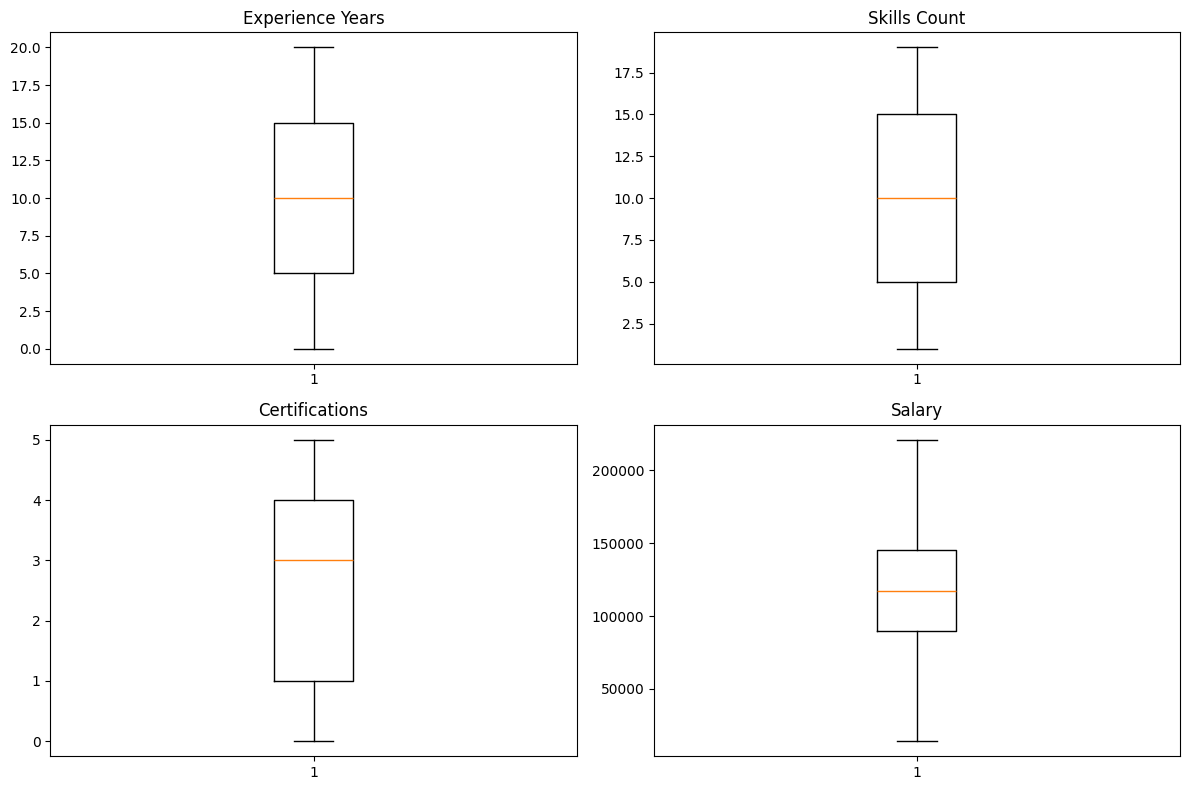

In [5]:


plt.figure(figsize=(12, 8))

# 1. Experience Years
plt.subplot(2, 2, 1)
plt.boxplot(df['experience_years'].dropna())
plt.title('Experience Years')

# 2. Skills Count
plt.subplot(2, 2, 2)
plt.boxplot(df['skills_count'].dropna())
plt.title('Skills Count')

# 3. Certifications
plt.subplot(2, 2, 3)
plt.boxplot(df['certifications'] .dropna())
plt.title('Certifications')

# 4. Salary
plt.subplot(2, 2, 4)
plt.boxplot(df['salary'].dropna())
plt.title('Salary')

plt.tight_layout()
plt.show()

In [6]:

df['education_level'] = df['education_level'].fillna('notknow')
df['company_size'] = df['company_size'].fillna('Unknown')
df['location'] = df['location'].fillna('Unknown')

# Numerical columns
df['experience_years'] = df['experience_years'].fillna(df['experience_years'].median())
df['skills_count'] = df['skills_count'].fillna(df['skills_count'].median())
df['certifications'] = df['certifications'].fillna(df['certifications'].median())

# Skills count should not be negative
df['skills_count'] = df['skills_count'].where(df['skills_count'] >= 0, np.nan)
df['skills_count'].fillna(df['skills_count'].median())

# Certifications should not be negative
df['certifications'] = df['certifications'].where(df['certifications'] >= 0, np.nan)
df['certifications'].fillna(df['certifications'].median())

print("Missing Values:\n", df.isnull().sum())
print("\nCleaned Dataset:\n")
df

Missing Values:
 job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64

Cleaned Dataset:



,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10.0,Bachelor,2.0,Healthcare,Medium,India,Hybrid,2.0,85270
1,Data Analyst,5.0,Bachelor,17.0,Telecom,Small,Australia,No,0.0,103860
2,Frontend Developer,18.0,PhD,4.0,Media,Unknown,Australia,No,1.0,126390
3,Business Analyst,19.0,PhD,13.0,Retail,Medium,Canada,Yes,0.0,162191
4,Product Manager,15.0,Bachelor,7.0,Manufacturing,Large,Sweden,Yes,0.0,118734
...,...,...,...,...,...,...,...,...,...,...
249995,Software Engineer,17.0,PhD,2.0,Telecom,Enterprise,India,No,1.0,115590
249996,Frontend Developer,20.0,PhD,7.0,Telecom,Startup,Remote,No,2.0,152738
249997,Business Analyst,1.0,Bachelor,12.0,Retail,Enterprise,India,Yes,0.0,69923
249998,Data Scientist,0.0,High School,2.0,Consulting,Small,Sweden,Hybrid,5.0,46351


In [7]:
print(df.info())
print(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   job_title         250000 non-null  str    
 1   experience_years  250000 non-null  float64
 2   education_level   250000 non-null  str    
 3   skills_count      250000 non-null  float64
 4   industry          250000 non-null  str    
 5   company_size      250000 non-null  str    
 6   location          250000 non-null  str    
 7   remote_work       250000 non-null  str    
 8   certifications    250000 non-null  float64
 9   salary            250000 non-null  int64  
dtypes: float64(3), int64(1), str(6)
memory usage: 19.1 MB
None
       experience_years   skills_count  certifications         salary
count     250000.000000  250000.000000   250000.000000  250000.000000
mean          10.006232       9.999136        2.495360  117510.722696
std            6.053064       5.454745        1.70

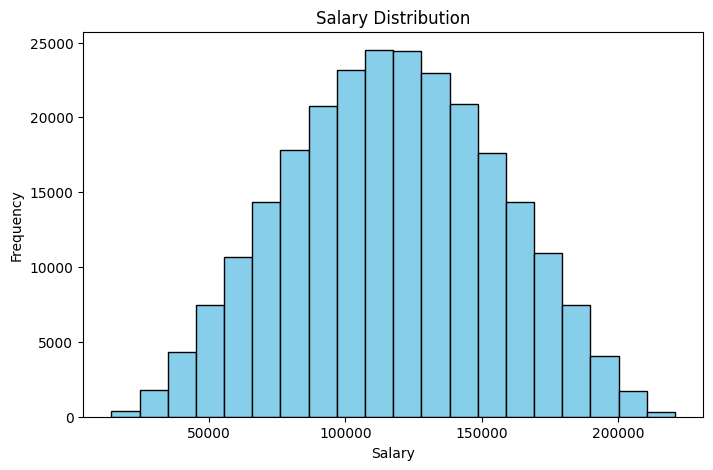

In [8]:
#Histogram Subplots
plt.figure(figsize=(8,5))

plt.hist(
    df['salary'],
    bins=20,
    color='skyblue',
    edgecolor='black'
)

plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Frequency")

plt.show()

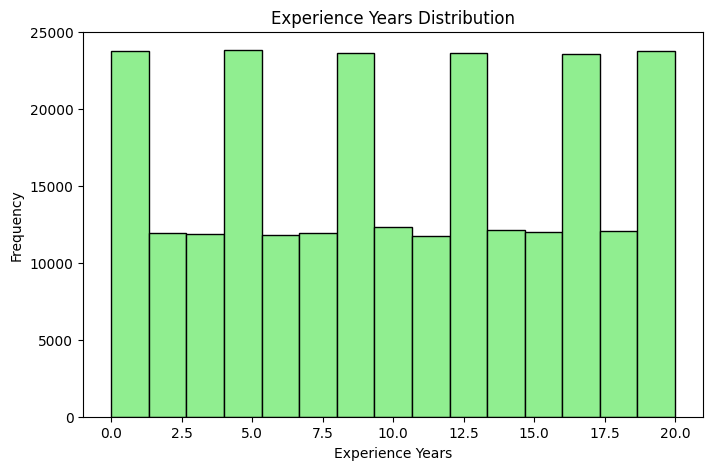

In [9]:
plt.figure(figsize=(8,5))

plt.hist(
    df['experience_years'],
    bins=15,
    color='lightgreen',
    edgecolor='black'
)

plt.title("Experience Years Distribution")
plt.xlabel("Experience Years")
plt.ylabel("Frequency")

plt.show()

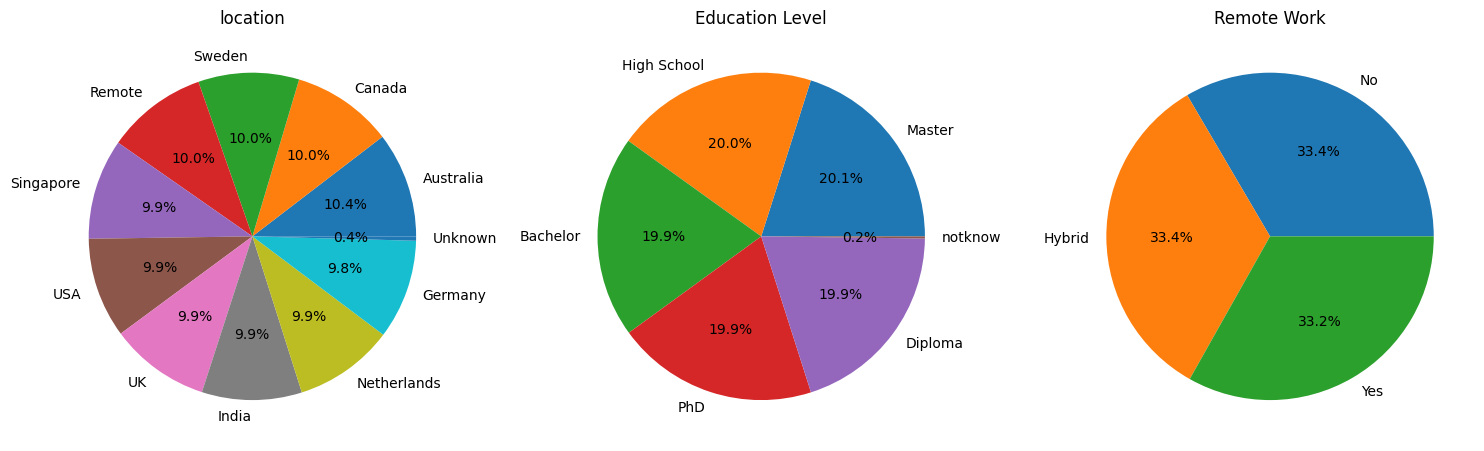

In [10]:
fig, ax = plt.subplots(1, 3, figsize=(15,5))

# 1. Job Title
loc_counts = df['location'].value_counts()
ax[0].pie(loc_counts, labels=loc_counts.index, autopct='%1.1f%%')
ax[0].set_title("location")

# 2. Education Level
edu_counts = df['education_level'].value_counts()
ax[1].pie(edu_counts, labels=edu_counts.index, autopct='%1.1f%%')
ax[1].set_title("Education Level")

# 3. Remote Work
remote_counts = df['remote_work'].value_counts()
ax[2].pie(remote_counts, labels=remote_counts.index, autopct='%1.1f%%')
ax[2].set_title("Remote Work")

plt.tight_layout()
plt.show()

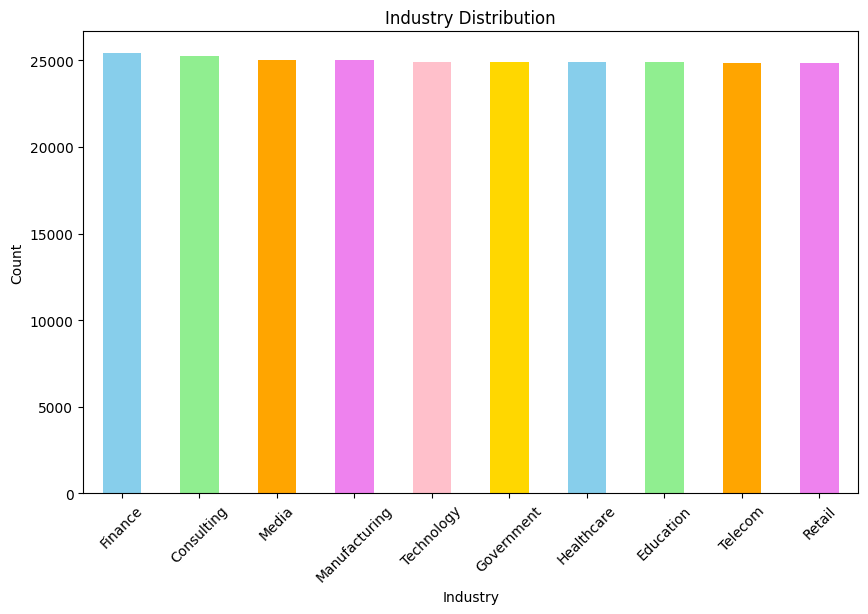

In [11]:
plt.figure(figsize=(10,6))

df['industry'].value_counts().plot(
    kind='bar',
    color=['skyblue', 'lightgreen', 'orange', 'violet', 'pink', 'gold']
)

plt.title("Industry Distribution")
plt.xlabel("Industry")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

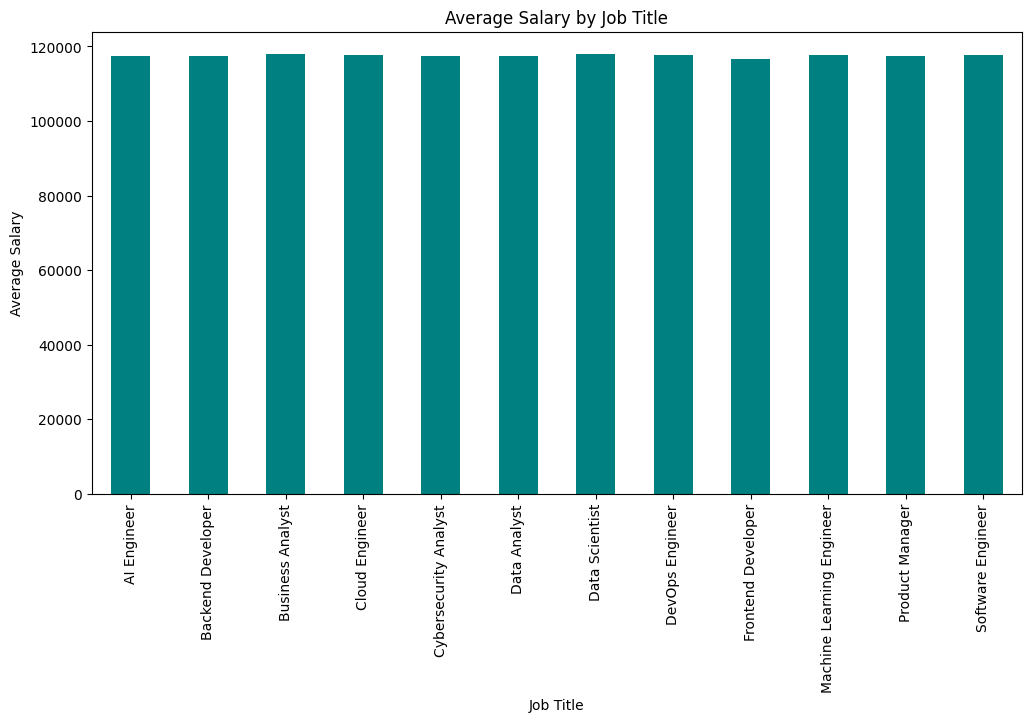

In [12]:
plt.figure(figsize=(12,6))

df.groupby('job_title')['salary'].mean().plot(
    kind='bar',
    color='teal'
)

plt.title("Average Salary by Job Title")
plt.xlabel("Job Title")
plt.ylabel("Average Salary")

plt.xticks(rotation=90)

plt.show()

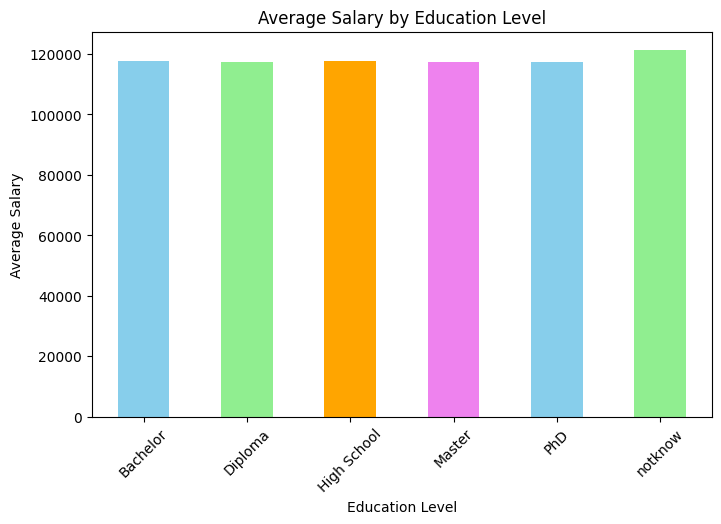

In [13]:
plt.figure(figsize=(8,5))

df.groupby('education_level')['salary'].mean().plot(
    kind='bar',
    color=['skyblue', 'lightgreen', 'orange', 'violet']
)

plt.title("Average Salary by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Average Salary")

plt.xticks(rotation=45)

plt.show()

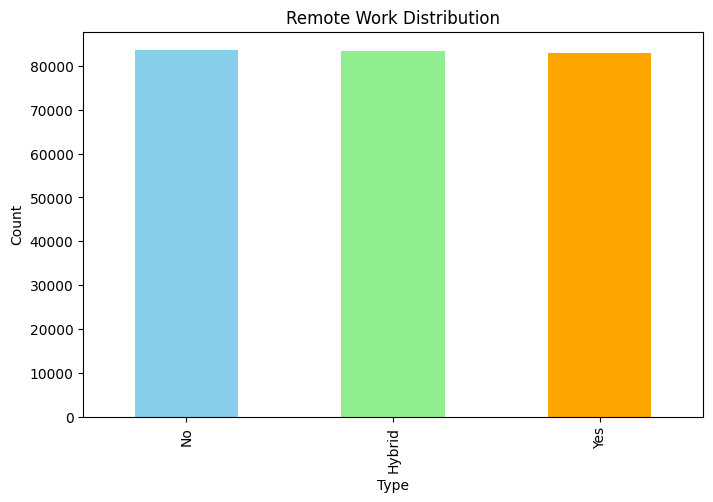

In [14]:
plt.figure(figsize=(8,5))

df['remote_work'].value_counts().plot(
    kind='bar',
    color=['skyblue', 'lightgreen', 'orange']
)

plt.title("Remote Work Distribution")
plt.xlabel("Type")
plt.ylabel("Count")

plt.show()

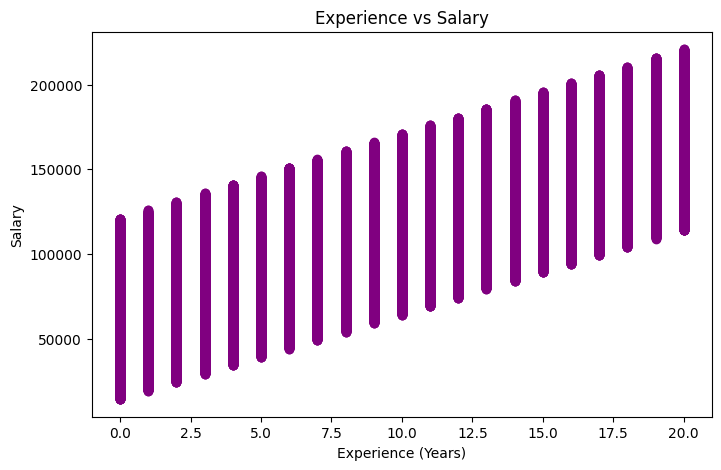

In [15]:
plt.figure(figsize=(8,5))

plt.scatter(
    df['experience_years'],
    df['salary'],
    color='purple'
)

plt.xlabel("Experience (Years)")
plt.ylabel("Salary")
plt.title("Experience vs Salary")

plt.show()

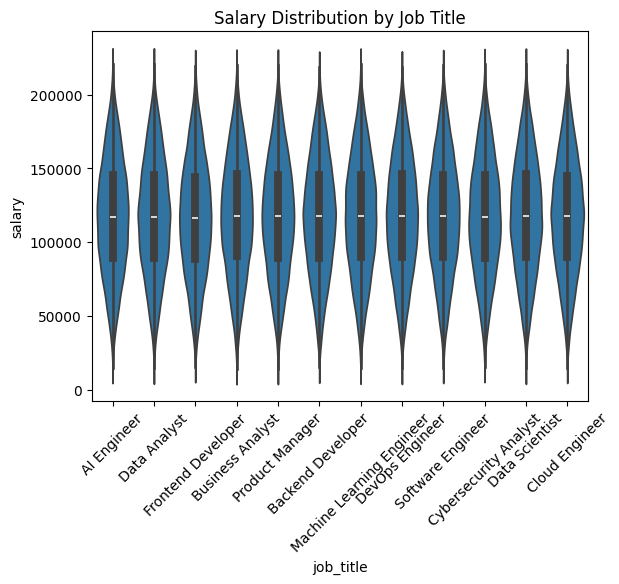

In [16]:

sns.violinplot(x='job_title', y='salary', data=df)

plt.xticks(rotation=45)
plt.title("Salary Distribution by Job Title")
plt.show()

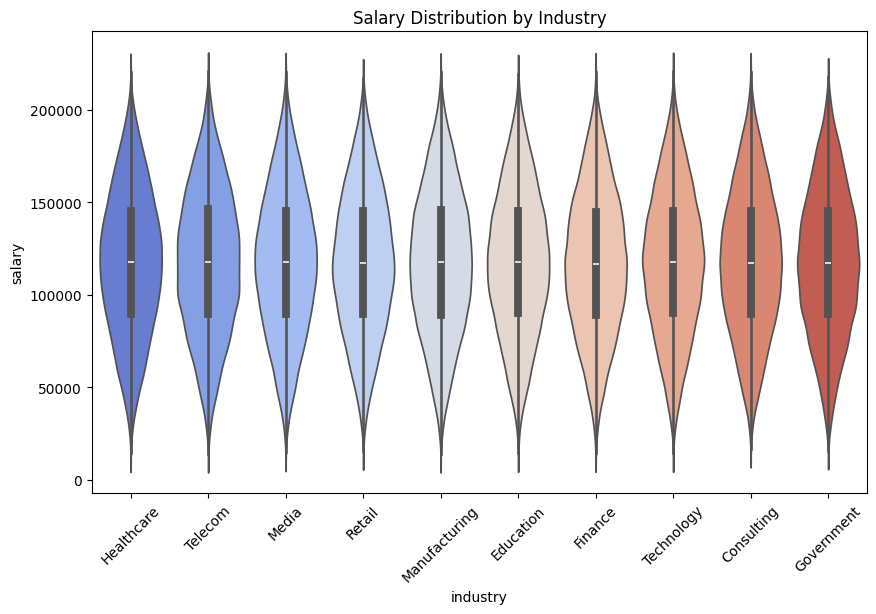

In [17]:
plt.figure(figsize=(10,6))

sns.violinplot(
    x='industry',
    y='salary',
    data=df,
    palette='coolwarm',
    hue='industry'
)

plt.title("Salary Distribution by Industry")

plt.xticks(rotation=45)

plt.show()

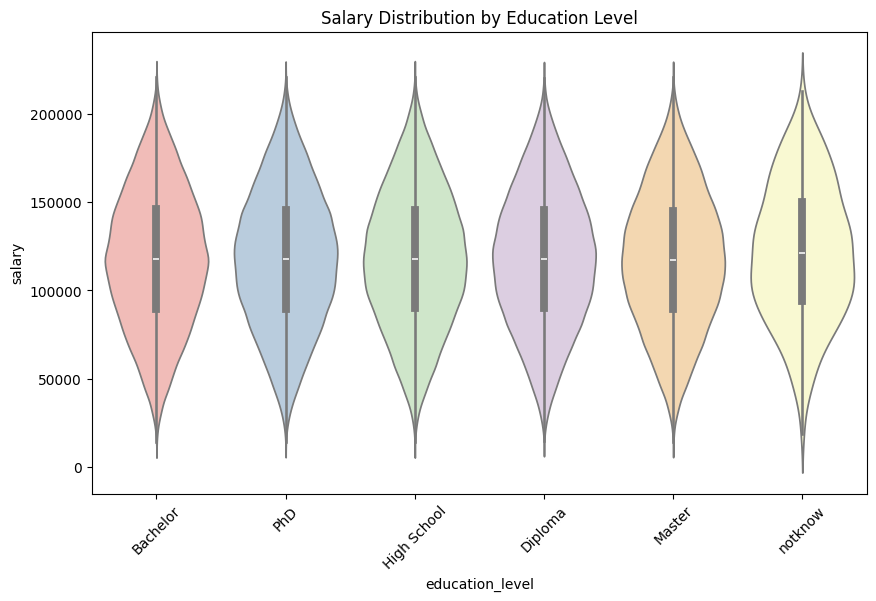

In [18]:
plt.figure(figsize=(10,6))

sns.violinplot(
    x='education_level',
    y='salary',
    data=df,
    palette='Pastel1',
    hue='education_level'
)

plt.title("Salary Distribution by Education Level")

plt.xticks(rotation=45)

plt.show()

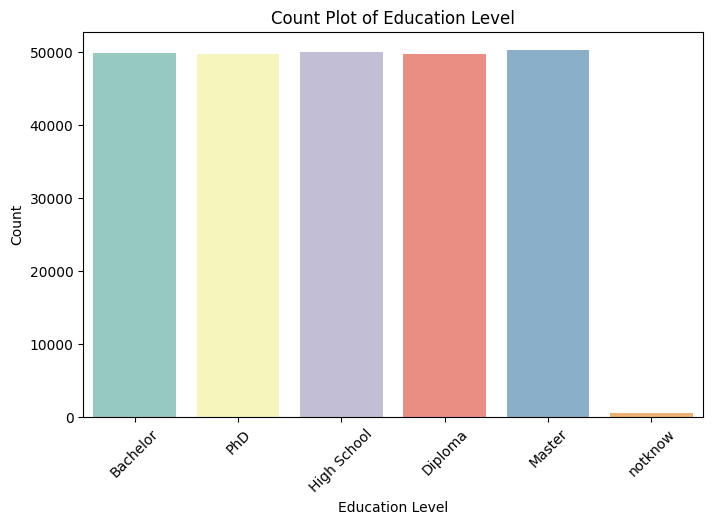

In [19]:

plt.figure(figsize=(8,5))

sns.countplot(
    x='education_level',
    data=df,
    palette='Set3',
    hue='education_level'
)

plt.xticks(rotation=45)

plt.title("Count Plot of Education Level")
plt.xlabel("Education Level")
plt.ylabel("Count")

plt.show()

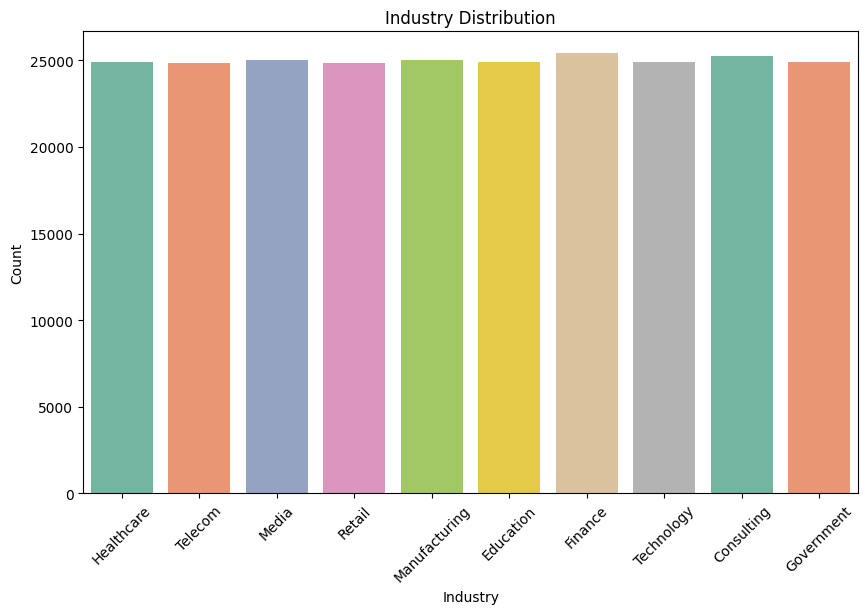

In [20]:
plt.figure(figsize=(10,6))

sns.countplot(
    x='industry',
    data=df,
    palette='Set2',
    hue='industry'
)

plt.title("Industry Distribution")
plt.xlabel("Industry")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

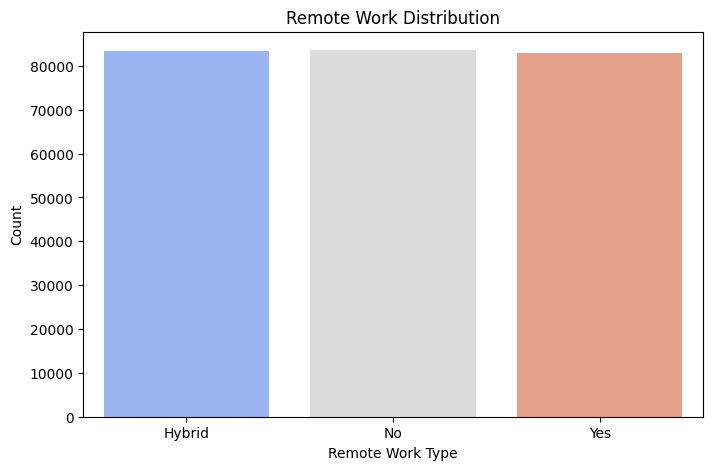

In [21]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='remote_work',
    data=df,
    palette='coolwarm',
    hue='remote_work'
)

plt.title("Remote Work Distribution")
plt.xlabel("Remote Work Type")
plt.ylabel("Count")

plt.show()

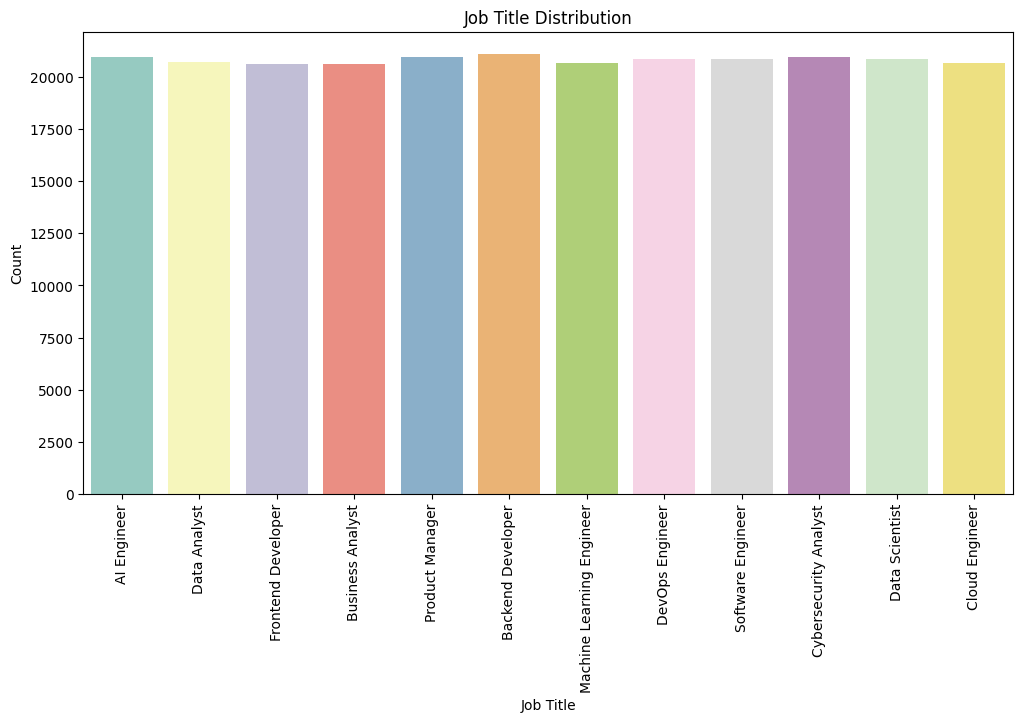

In [22]:
plt.figure(figsize=(12,6))

sns.countplot(
    x='job_title',
    data=df,
    palette='Set3',
    hue='job_title'
)

plt.title("Job Title Distribution")
plt.xlabel("Job Title")
plt.ylabel("Count")

plt.xticks(rotation=90)

plt.show()

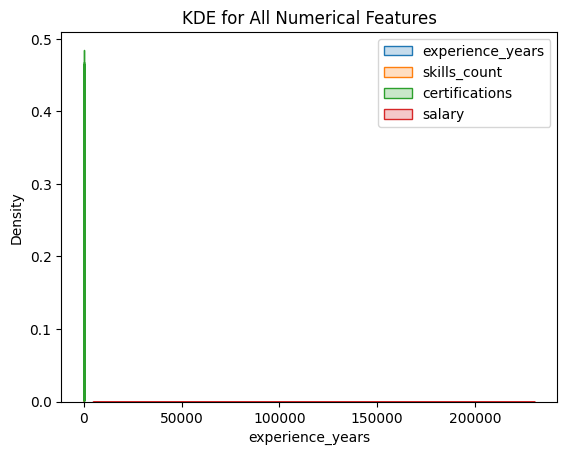

In [23]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    sns.kdeplot(df[col], label=col, fill=True)

plt.legend()
plt.title("KDE for All Numerical Features")
plt.show()

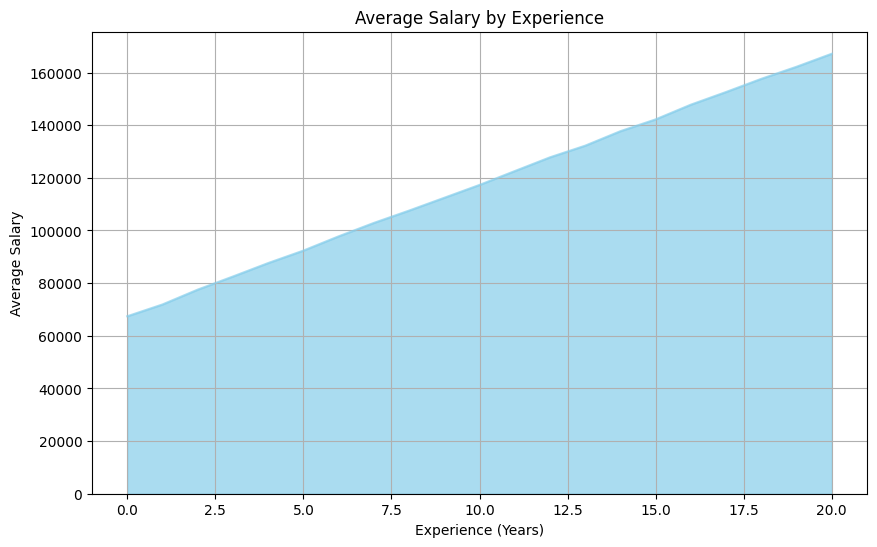

In [24]:
plt.figure(figsize=(10,6))

df.groupby('experience_years')['salary'].mean().plot(
    kind='area',
    color='skyblue',
    alpha=0.7
)

plt.title("Average Salary by Experience")
plt.xlabel("Experience (Years)")
plt.ylabel("Average Salary")

plt.grid(True)

plt.show()

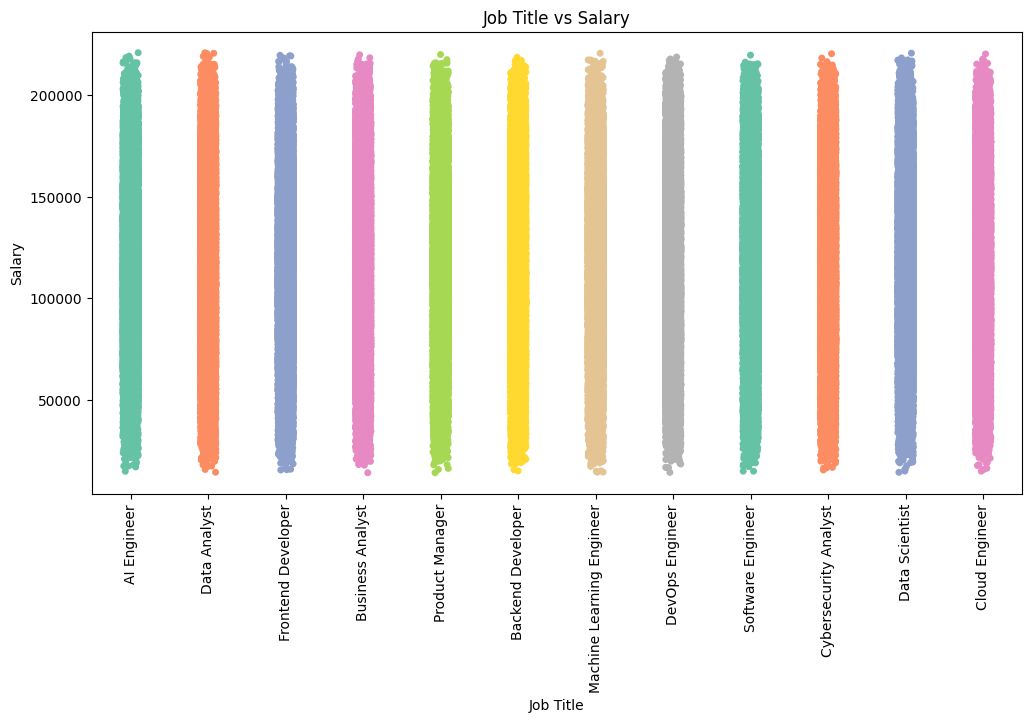

In [25]:
plt.figure(figsize=(12,6))

sns.stripplot(
    x='job_title',
    y='salary',
    data=df,
    jitter=True,
    palette='Set2',
    hue='job_title'
)

plt.title("Job Title vs Salary")
plt.xlabel("Job Title")
plt.ylabel("Salary")

plt.xticks(rotation=90)

plt.show()

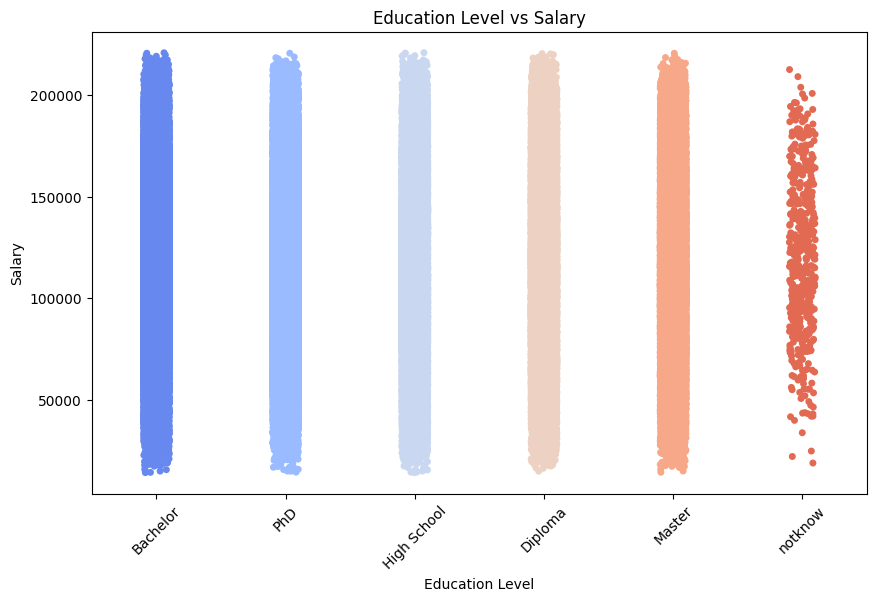

In [26]:
plt.figure(figsize=(10,6))

sns.stripplot(
    x='education_level',
    y='salary',
    data=df,
    jitter=True,
    palette='coolwarm',
    hue='education_level'
)

plt.title("Education Level vs Salary")
plt.xlabel("Education Level")
plt.ylabel("Salary")

plt.xticks(rotation=45)

plt.show()

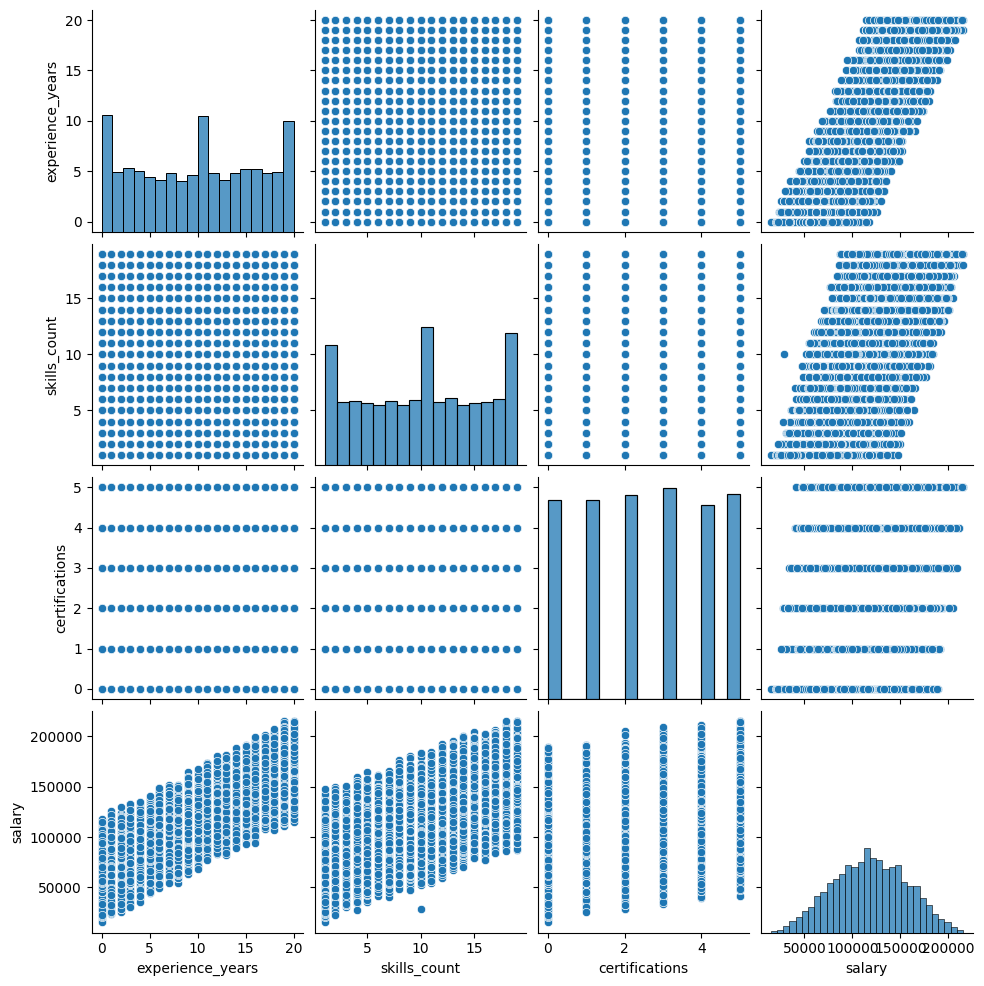

In [27]:
sns.pairplot(df.sample(5000))
plt.show()


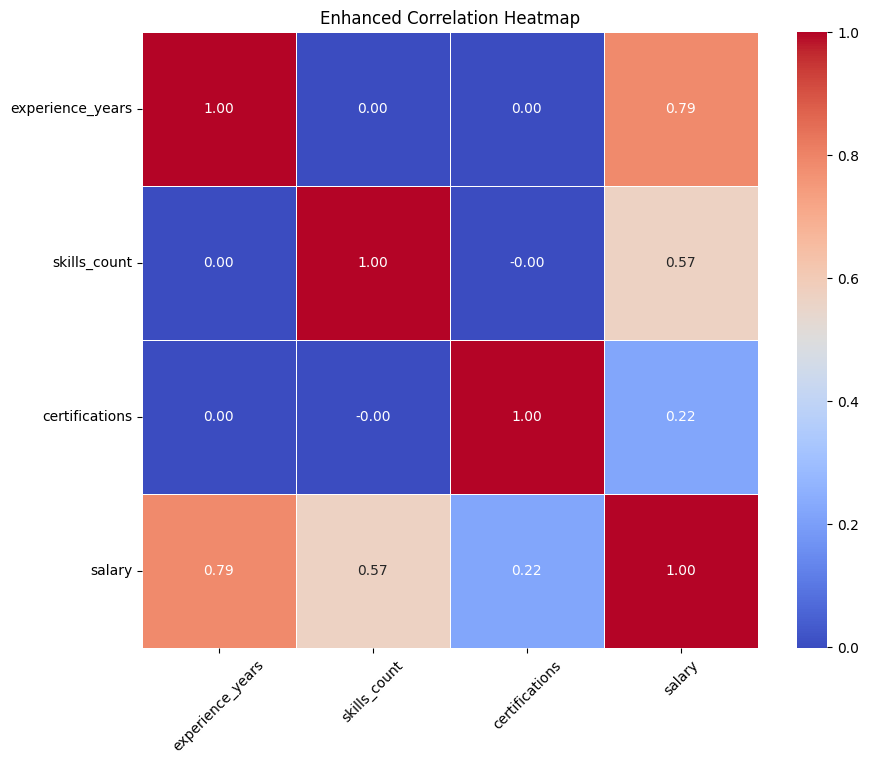

In [28]:

corr = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True,
    cbar=True
)

plt.title("Enhanced Correlation Heatmap")
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.show()

In [29]:
# =========================
# IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


# =========================
# REDUCE SIZE (OPTIONAL)
# =========================
df = df.sample(n=50000, random_state=42)

# =========================
# FEATURE ENGINEERING
# =========================
df['exp_squared'] = df['experience_years'] ** 2
df['skill_per_exp'] = df['skills_count'] / (df['experience_years'] + 1)
df['cert_per_skill'] = df['certifications'] / (df['skills_count'] + 1)

df['seniority'] = pd.cut(
    df['experience_years'],
    bins=[0, 2, 5, 10, 20],
    labels=['Fresher', 'Junior', 'Mid', 'Senior']
)

# =========================
# ENCODING
# =========================
cat_cols = ['job_title', 'education_level', 'location', 'industry',
            'company_size', 'remote_work', 'seniority']

df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# =========================
# FEATURES & TARGET
# =========================
X = df.drop('salary', axis=1)
y = df['salary']

# =========================
# TRAIN TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# SCALING (NUMERIC ONLY)
# =========================
num_cols = ['experience_years', 'skills_count', 'certifications',
            'exp_squared', 'skill_per_exp', 'cert_per_skill']

scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# =========================
# TRAIN KNN
# =========================
knn = KNeighborsRegressor(n_neighbors=7)
knn.fit(X_train, y_train)

# =========================
# EVALUATION
# =========================
y_pred = knn.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("🔹 Model Performance")
print("R2 Score:", r2)
print("MAE:", mae)
print("MSE:", mse)

# =========================
# SAVE EVERYTHING
# =========================
pickle.dump(knn, open("knn_model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))
pickle.dump(X.columns.tolist(), open("columns.pkl", "wb"))

print("✅ Model ready for deployment!")

🔹 Model Performance
R2 Score: 0.9552185982892919
MAE: 6436.973871428571
MSE: 65631722.0534551
✅ Model ready for deployment!
